In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.neural_network import MLPClassifier, MLPRegressor
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = 'Base de datos experimento combustión dtrees.xlsx'
df = pd.read_excel(file_path)

# Removing extra spaces in column names
df.rename(columns=lambda x: x.strip(), inplace=True)

# Dropping rows with missing values
df_cleaned = df.dropna()
df_cleaned.tail(5)

,Eng Displ,# Cyl,City FE (Guide) - Conventional Fuel,Hwy FE (Guide) - Conventional Fuel,Comb FE (Guide) - Conventional Fuel,Trans Desc,# Gears,Drive Desc,Fuel Usage,Carline Class Desc,Descriptor - Model Type,FE Rating,Comb CO2 Rounded Adjusted (as shown on FE Label),Guzzler?,Gas Guzzler Exempt
958,2.5,4.0,35.0,35.0,35.0,Selectable Continuously Variable (e.g. CVT wit...,6.0,All Wheel Drive,Gasoline (Regular Unleaded Recommended),Standard SUV 4WD,1.0,7.0,254.0,0.0,1
959,2.5,4.0,35.0,34.0,35.0,Selectable Continuously Variable (e.g. CVT wit...,6.0,All Wheel Drive,Gasoline (Regular Unleaded Recommended),Standard SUV 4WD,1.0,7.0,253.0,0.0,1
960,2.4,4.0,22.0,25.0,23.0,Semi-Automatic,8.0,4-Wheel Drive,Gasoline (Premium Unleaded Required),Standard SUV 4WD,1.0,5.0,380.0,0.0,1
961,3.4,6.0,19.0,22.0,20.0,Semi-Automatic,10.0,Part-time 4-Wheel Drive,Gasoline (Regular Unleaded Recommended),Standard SUV 4WD,1.0,4.0,439.0,0.0,1
962,2.0,4.0,22.0,27.0,24.0,Semi-Automatic,8.0,All Wheel Drive,Gasoline (Premium Unleaded Required),Standard SUV 4WD,0.0,5.0,369.0,0.0,1


In [3]:
# Selecting the features and target
X_cleaned = df_cleaned[['Eng Displ', '# Cyl', 'Trans Desc', '# Gears', 'Drive Desc', 'Fuel Usage', 'Descriptor - Model Type',"Gas Guzzler Exempt"]]
y_cleaned = df_cleaned['Guzzler?']

X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.4, random_state=2)
categorical_features = ['Trans Desc', 'Drive Desc', 'Fuel Usage',"Gas Guzzler Exempt"]
one_hot_encoder = OneHotEncoder(handle_unknown='ignore')
numerical_features = ['Eng Displ', '# Cyl', '# Gears', 'Descriptor - Model Type']
scaler = StandardScaler()
# Defining the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', one_hot_encoder, categorical_features)
    ],
    remainder='passthrough'
)

Cross-Validation Accuracy Scores: [0.96153846 0.94805195 0.97402597 0.98701299 0.97402597]
Mean Cross-Validation Accuracy: 0.968931068931069
Standard Deviation of Cross-Validation Accuracy: 0.013186813186813185

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.95      0.98       365
         1.0       0.55      1.00      0.71        21

    accuracy                           0.96       386
   macro avg       0.78      0.98      0.84       386
weighted avg       0.98      0.96      0.96       386



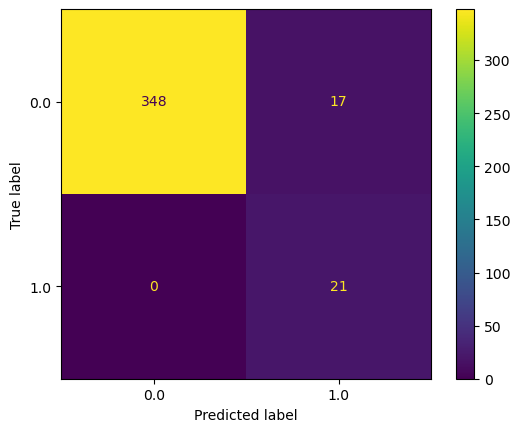

In [4]:

# Defining the decision tree classifier
# Defining the DecisionTree classifier with hyperparameter tuning
classifier = DecisionTreeClassifier(random_state=42)
param_grid = {
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion': ['gini', 'entropy']
}

# Creating the pipeline
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', classifier)])

# Using GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model after hyperparameter tuning
best_model = grid_search.best_estimator_

# Evaluar el mejor modelo con validación cruzada
cv_scores = cross_val_score(best_model, X_test, y_test, cv=5, scoring='accuracy')

# Mostrar los resultados de la validación cruzada
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Cross-Validation Accuracy:", np.mean(cv_scores))
print("Standard Deviation of Cross-Validation Accuracy:", np.std(cv_scores))

# Predicciones en el conjunto de prueba
y_pred = best_model.predict(X_test)

# Mostrar el reporte de clasificación
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

# Graficar la matriz de confusión
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

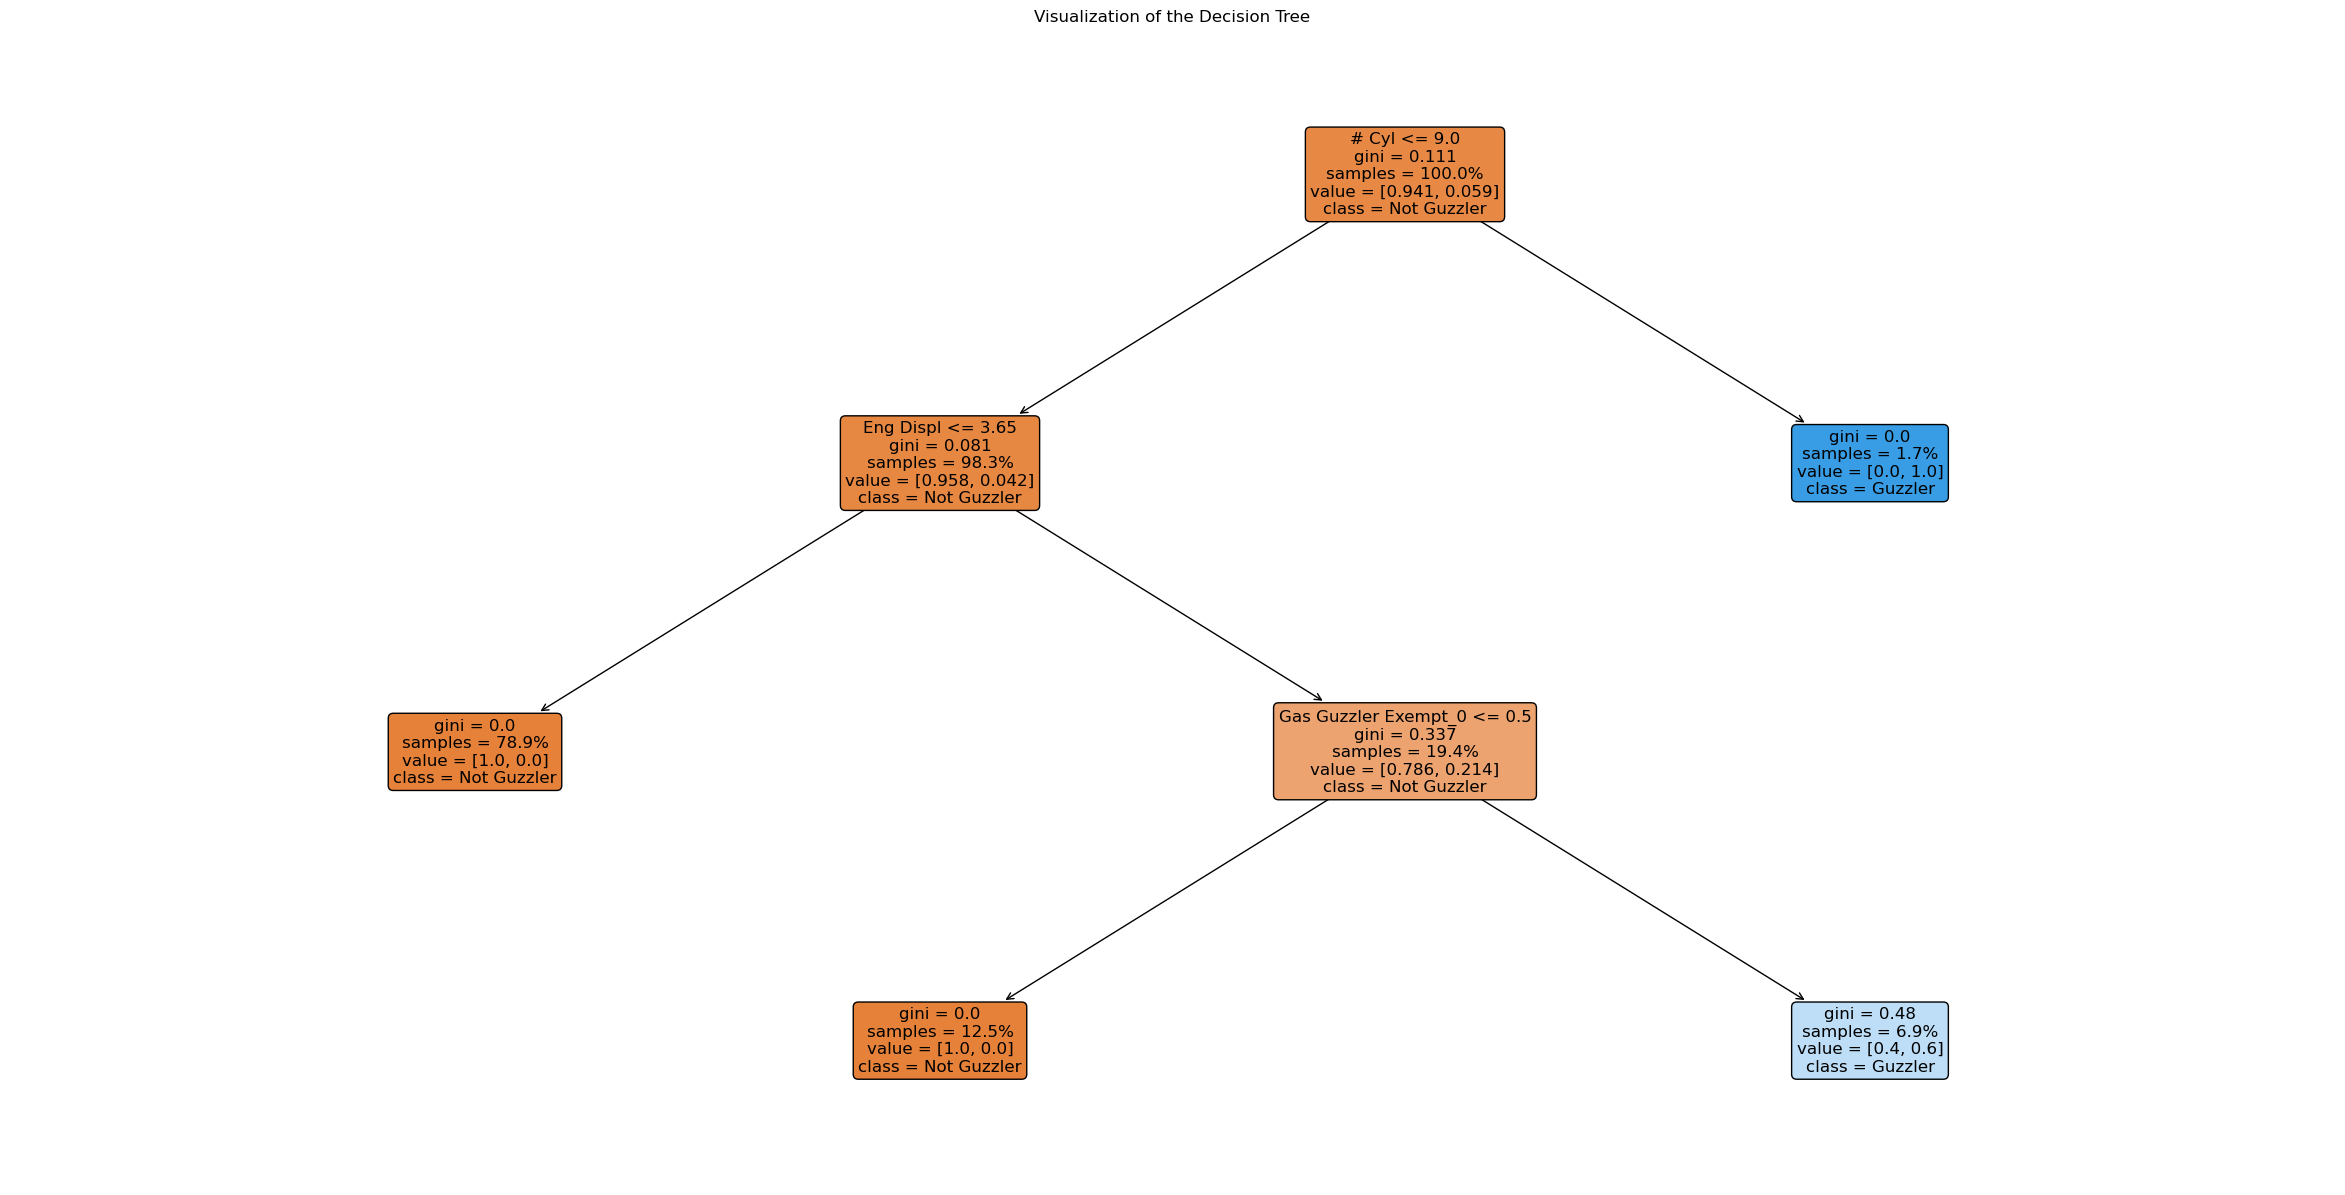

In [5]:
# Plotting the decision tree
# Plotting the decision tree
best_classifier = best_model.named_steps['classifier']
plt.figure(figsize=(30, 15))  # Increase figure size for better readability
plot_tree(best_classifier, 
          filled=True, 
          feature_names=one_hot_encoder.fit(X_cleaned[categorical_features]).get_feature_names_out(categorical_features).tolist() + numerical_features,
          rounded=True, 
          class_names=['Not Guzzler', 'Guzzler'],
          fontsize=12, 
          proportion=True)  # Use proportion=True to make nodes more separated
plt.title("Visualization of the Decision Tree")
plt.show()

Vamos a interpretar el D Tree obtenido: 
El nodo raíz es aquel que divide los datos entre coches de más de 9 cilindros o de menos de 9 cilindros. Como los motores de 10 cilindros en adelante (no existen motores de 9 cilindros) son, a día de hoy, patrimonio exclusivo de deportivos de muy alta potencia o de berlinas del segmento F, y, tal y como se ve en el nodo, susceptibles en su totalidad de ser incluidos en la tasa "Gas Guzzler". 
Como podemos apreciar, estos vehículos suponen un porcentaje realmente pequeño de toda la muestra, apenas un 1,7%.

Pasando al siguiente nodo, vemos que el gini se reduce levemente: Aquí dividimos la muestra entre vehículos que tienen una cilindrada superior o inferior a 3,65 litros. Si es inferior, como podemos ver, el programa clasifica todos los vehículos como "not guzzler", mientras que si es superior, pasamos al siguiente nodo. Este criterio, el de la cilindrada, ya ayuda a clasificar como no gas guzzler al 78,9% de la muestra, lo que da una idea de la potencia de este nodo. 

En el siguiente nodo, el programa analiza el 19,4% restante y lo divide en vehículos exentos de la tasa gas guzzler y no exentos. Los exentos tiene claro que no son gas guzzler, pero en cuanto a los no exentos, sigue presentando confusión, con un gini que llega a 0,48. Vamos a hacer algunas validaciones extras del modelo para garantizar que es seguro:

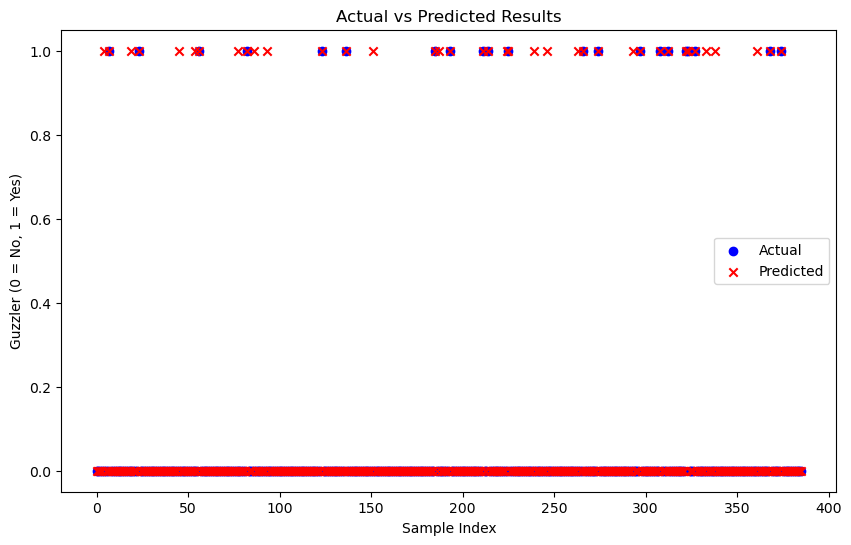

In [6]:
# Representamos gráficamente los resultados obtenidos y los que debieran ser
plt.figure(figsize=(10, 6))
x_axis = np.arange(len(y_test))
plt.scatter(x_axis, y_test, color='blue', label='Actual', marker='o')
plt.scatter(x_axis, y_pred, color='red', label='Predicted', marker='x')
plt.xlabel('Sample Index')
plt.ylabel('Guzzler (0 = No, 1 = Yes)')
plt.title('Actual vs Predicted Results')
plt.legend()
plt.show()

In [7]:
df = df.dropna()
# Selección de las columnas relevantes
X = df[['Eng Displ', '# Cyl', 'Trans Desc', '# Gears', 'Drive Desc',"Carline Class Desc", 'Fuel Usage', 'Descriptor - Model Type',"Gas Guzzler Exempt"]]
y = df['Guzzler?']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Preprocesamiento
# Definir las columnas categóricas para el One-Hot-Encoding
categorical_features = ['Trans Desc', 'Drive Desc', 'Fuel Usage', "Carline Class Desc", "Gas Guzzler Exempt"]
numeric_features = ['Eng Displ', '# Cyl', '# Gears']

# Definir un ColumnTransformer para realizar One-Hot-Encoding y escalado de las características numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Crear el pipeline de preprocesamiento
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Preprocesar los datos de entrenamiento y prueba
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Construcción del modelo con scikit-learn
model = MLPClassifier(hidden_layer_sizes=(128, 64, 32, 16), activation='relu', solver='adam', max_iter=1000, random_state=42)

# Entrenamiento del modelo
model.fit(X_train_processed, y_train)

# Evaluación del modelo
y_pred = model.predict(X_test_processed)
test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy:.2f}')
print(classification_report(y_test, y_pred))



Test Accuracy: 0.97
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       362
         1.0       0.74      0.71      0.72        24

    accuracy                           0.97       386
   macro avg       0.86      0.85      0.85       386
weighted avg       0.97      0.97      0.97       386



Test Accuracy: 0.97
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       362
         1.0       0.74      0.71      0.72        24

    accuracy                           0.97       386
   macro avg       0.86      0.85      0.85       386
weighted avg       0.97      0.97      0.97       386



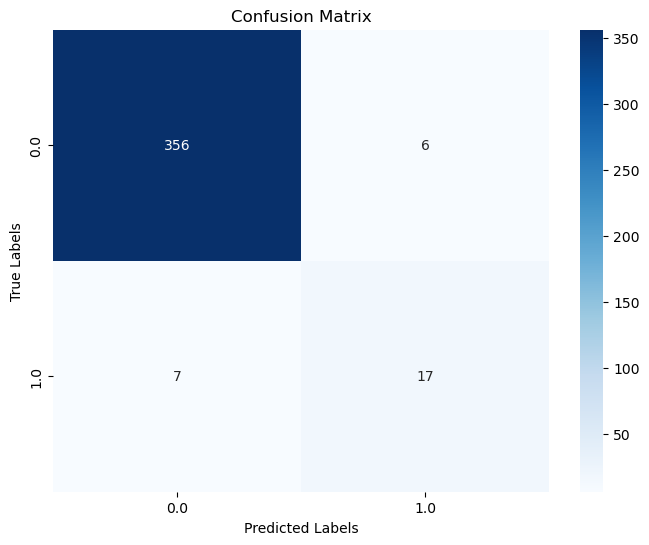

In [11]:
# Importar las bibliotecas necesarias
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = model.predict(X_test_processed)
test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy:.2f}')
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


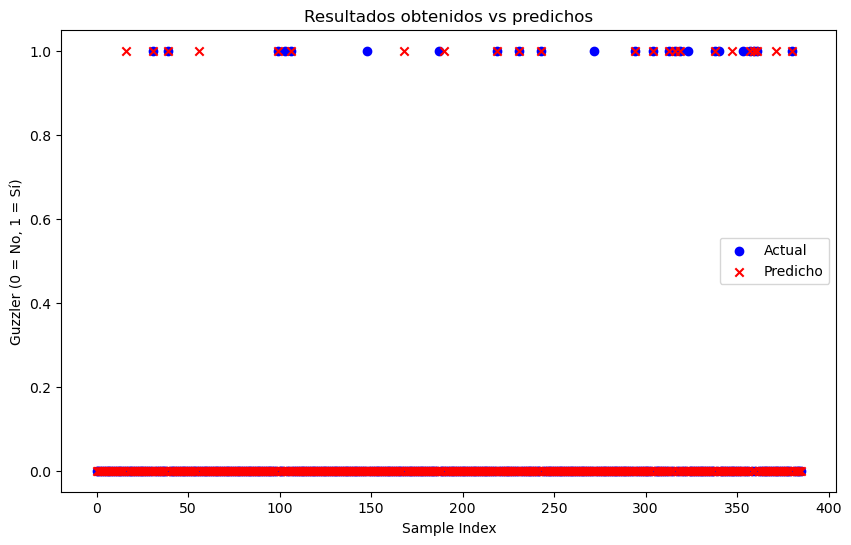

In [159]:
# Representamos gráficamente los resultados obtenidos y los que debieran ser
plt.figure(figsize=(10, 6))
x_axis = np.arange(len(y_test))
plt.scatter(x_axis, y_test, color='blue', label='Actual', marker='o')
plt.scatter(x_axis, y_pred, color='red', label='Predicho', marker='x')
plt.xlabel('Sample Index')
plt.ylabel('Guzzler (0 = No, 1 = Sí)')
plt.title('Resultados obtenidos vs predichos')
plt.legend()
plt.show()